In [ ]:
# IMPORT LIBRARY

import pandas as pd
import numpy as np
import pyarrow as pa

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.inspection import permutation_importance

from lightgbm import LGBMClassifier

import joblib

In [2]:
# LOAD DATA
df = pd.read_parquet("data/clean_yellow_taxi_2024_q1.parquet")
df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_minutes,average_speed_mph,tip_percentage,high_tip
0,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.8,1.0,N,140,236,1,...,3.75,0.0,1.0,18.75,2.5,0.0,6.600000,16.363636,0.375000,1
1,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.7,1.0,N,236,79,1,...,3.00,0.0,1.0,31.30,2.5,0.0,17.916667,15.739535,0.128755,0
2,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.4,1.0,N,79,211,1,...,2.00,0.0,1.0,17.00,2.5,0.0,8.300000,10.120482,0.200000,1
3,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.8,1.0,N,211,148,1,...,3.20,0.0,1.0,16.10,2.5,0.0,6.100000,7.868852,0.405063,1
4,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1.0,4.7,1.0,N,148,141,1,...,6.90,0.0,1.0,41.50,2.5,0.0,32.383333,8.708183,0.233108,1


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6373879 entries, 0 to 6373878
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

# Feature Engnineer

### Explanation: 
Feature engineering is the process of transforming the cleaned taxi trip dataset into meaningful predictors for the high-tip classification problem. In this project, the target variable is `high_tip`, which identifies whether a credit-card taxi ride receives a tip percentage of at least 20%. Therefore, the engineered features should describe the trip context, time pattern, fare structure, and location behavior that may be associated with stronger tipping behavior.

This project is framed as a completed-trip prediction case study rather than a real-time pre-trip prediction system. Because of this framing, features that are known after the trip is completed, such as trip duration, fare amount, average speed, and drop-off location, can be used for modeling. However, direct tip-related variables such as `tip_amount`, `tip_percentage`, `high_tip`, and `total_amount` are excluded from the feature set to prevent data leakage.

The feature engineering process is organized into four main groups. First, **<span style="color: blue;">time-based</span>** features are created to capture when the ride happened, such as pickup hour, day of week, weekend trips, rush-hour trips, and night trips. Second, **<span style="color: blue;">trip-based</span>** features are used to describe the physical characteristics of the ride, including trip distance, trip duration, average speed, and passenger count. Third, **<span style="color: blue;">fare-based</span>** features capture the payment structure of the ride, such as fare amount, tolls, congestion surcharge, and airport fee. Finally, **<span style="color: blue;">location-based</span>** features describe where the trip started and ended, including pickup zone, drop-off zone, same-zone trips, and airport-related trips.

Instead of adding all features at once, the modeling process will evaluate these feature groups progressively. The model is first tested with time features only, then trip and fare features are added, and finally location features are included. This staged design makes the analysis more interpretable because it allows us to observe how much each feature group contributes to predicting high-tip rides.

Overall, the goal of feature engineering in this project is not only to improve model performance, but also to create a clear and explainable connection between raw taxi trip records and customer tipping behavior.

#### Time-based features

In [4]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
df["pickup_day_name"] = df["tpep_pickup_datetime"].dt.day_name()

df["is_weekend"] = df["pickup_day_of_week"].isin([5, 6]).astype(int)

df["is_rush_hour"] = (
    ((df["pickup_hour"] >= 7) & (df["pickup_hour"] <= 10)) |
    ((df["pickup_hour"] >= 16) & (df["pickup_hour"] <= 19))
).astype(int)

df["is_night_trip"] = (
    (df["pickup_hour"] >= 22) | (df["pickup_hour"] <= 5)
).astype(int)

time_features = [
    "pickup_hour",
    "pickup_day_of_week",
    "is_weekend",
    "is_rush_hour",
    "is_night_trip"
]

df[time_features].head()

,pickup_hour,pickup_day_of_week,is_weekend,is_rush_hour,is_night_trip
0,0,0,0,0,1
1,0,0,0,0,1
2,0,0,0,0,1
3,0,0,0,0,1
4,0,0,0,0,1


#### Trip-based features

In [5]:
trip_features = [
    "trip_distance",
    "trip_duration_minutes",
    "average_speed_mph",
    "passenger_count"
]

df[trip_features].describe()
df[trip_features].isna().sum()
np.isinf(df[trip_features]).sum()

trip_distance            0
trip_duration_minutes    0
average_speed_mph        0
passenger_count          0
dtype: int64

#### Fare-based features

This process would not include `total_amount` because it may contain tip-related information and can leak the target. Also, I would keep `mta_tax` and `improvement_surcharge` out for now because they are mostly fixed charges, so they usually add little predictive value.

In [6]:
if "Airport_fee" in df.columns:
    df = df.rename(columns={"Airport_fee": "airport_fee"})

fare_base_cols = [
    "fare_amount",
    "tolls_amount",
    "congestion_surcharge",
    "airport_fee" 
]

df[["tolls_amount", "congestion_surcharge", "airport_fee"]] = (
    df[["tolls_amount", "congestion_surcharge", "airport_fee"]].fillna(0)
)

df["has_tolls"] = (df["tolls_amount"] > 0).astype(int)
df["has_congestion_surcharge"] = (df["congestion_surcharge"] > 0).astype(int)
df["has_airport_fee"] = (df["airport_fee"] > 0).astype(int)

fare_features = [
    "fare_amount",
    "tolls_amount",
    "congestion_surcharge",
    "airport_fee",
    "has_tolls",
    "has_congestion_surcharge",
    "has_airport_fee"
]

df[fare_features].head()

,fare_amount,tolls_amount,congestion_surcharge,airport_fee,has_tolls,has_congestion_surcharge,has_airport_fee
0,10.0,0.0,2.5,0.0,0,1,0
1,23.3,0.0,2.5,0.0,0,1,0
2,10.0,0.0,2.5,0.0,0,1,0
3,7.9,0.0,2.5,0.0,0,1,0
4,29.6,0.0,2.5,0.0,0,1,0


#### Location-based features

For location-based features, pickup and drop-off locations are kept as categorical zone IDs. A `same_zone_trip` feature is created to identify trips that start and end in the same taxi zone. Since airport-related information is already represented by the `has_airport_fee` feature in the fare-based feature group, no additional airport-location flag is created. This avoids unnecessary feature duplication while keeping the feature set simple and interpretable.

In [7]:
df["same_zone_trip"] = (
    df["PULocationID"] == df["DOLocationID"]
).astype(int)

df["PULocationID"] = df["PULocationID"].astype("category")
df["DOLocationID"] = df["DOLocationID"].astype("category")

location_features = [
    "PULocationID",
    "DOLocationID",
    "same_zone_trip"
]

df[location_features].head()

,PULocationID,DOLocationID,same_zone_trip
0,140,236,0
1,236,79,0
2,79,211,0
3,211,148,0
4,148,141,0


# Modeling 

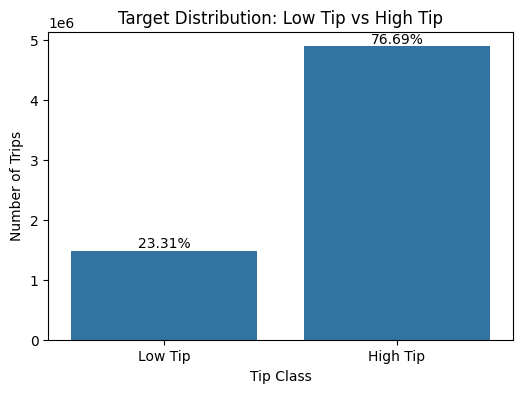

In [21]:
target_col = "high_tip"

target_counts = df[target_col].value_counts().sort_index()
target_percent = df[target_col].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "Class": ["Low Tip", "High Tip"],
    "Count": target_counts.values,
    "Percentage": target_percent.values
})

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x=target_col
)

plt.title("Target Distribution: Low Tip vs High Tip")
plt.xlabel("Tip Class")
plt.ylabel("Number of Trips")
plt.xticks([0, 1], ["Low Tip", "High Tip"])

total = len(df)

for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f"{percentage:.2f}%",
        (p.get_x() + p.get_width() / 2, count),
        ha="center",
        va="bottom"
    )

plt.show()

### Target Distribution and Class Imbalance

Before training the models, the distribution of the target variable was inspected. The target variable `high_tip` is defined as 1 when the tip percentage is at least 20%, and 0 otherwise.

The distribution shows that high-tip rides are the majority class in the dataset. This means the classification problem is imbalanced. If this imbalance is ignored, a model may achieve high accuracy or high recall simply by predicting most rides as high-tip. Therefore, accuracy and recall alone may give an overly optimistic view of model performance.

To address this issue, `class_weight="balanced"` is applied during model training. This gives more weight to the minority class and less weight to the majority class. As a result, the models are encouraged to learn patterns from both low-tip and high-tip rides instead of being biased toward the majority class.

## Evaluation Metrics

Since this project is a binary classification problem, the model predicts whether a taxi ride belongs to the high-tip class (`high_tip = 1`) or the low-tip class (`high_tip = 0`). Model performance is evaluated using multiple metrics rather than accuracy alone because the target variable may be moderately imbalanced. If one class appears more often than the other, accuracy can look high even when the model performs poorly on the more important class.

The following metrics are used to evaluate the models:

**Accuracy** measures the proportion of total predictions that are correct. It gives a general overview of model performance, but it is not sufficient by itself when the target classes are imbalanced.

**Precision** measures, among the rides predicted as high-tip, how many are actually high-tip rides. In this project, precision answers the question: when the model predicts a ride as high-tip, how often is it correct?

**Recall** measures, among all actual high-tip rides, how many are successfully identified by the model. In this project, recall answers the question: how many real high-tip rides can the model capture?

**F1-score** combines precision and recall into one metric. It is useful when we want a balanced view of the model’s ability to identify high-tip rides without over-predicting them.

**ROC-AUC** measures how well the model separates high-tip and low-tip rides across different classification thresholds. A higher ROC-AUC means the model is better at ranking high-tip rides above low-tip rides.

**PR-AUC** measures the trade-off between precision and recall across different thresholds. It is especially useful when the positive class is imbalanced, because it focuses more directly on the model’s performance for the high-tip class.

**Confusion matrix** shows the number of true positives, false positives, true negatives, and false negatives. This helps interpret what types of mistakes the model makes.

**Top-k lift** evaluates the model from a business perspective. Instead of only asking whether each individual prediction is correct, it asks whether the model can rank rides so that the top 10%, 20%, or 30% contain a higher concentration of high-tip rides than random selection.

In [9]:
target_col = "high_tip"

leakage_cols = [
    "tip_amount",
    "tip_percentage",
    "high_tip",
    "total_amount"
]

feature_cols = (
    time_features
    + trip_features
    + fare_features
    + location_features
)

feature_cols = [col for col in feature_cols if col in df.columns]

feature_cols = [col for col in feature_cols if col not in leakage_cols]

X = df[feature_cols]
y = df[target_col]

print("Number of features:", len(feature_cols))
print("Features used:")
print(feature_cols)

Number of features: 19
Features used:
['pickup_hour', 'pickup_day_of_week', 'is_weekend', 'is_rush_hour', 'is_night_trip', 'trip_distance', 'trip_duration_minutes', 'average_speed_mph', 'passenger_count', 'fare_amount', 'tolls_amount', 'congestion_surcharge', 'airport_fee', 'has_tolls', 'has_congestion_surcharge', 'has_airport_fee', 'PULocationID', 'DOLocationID', 'same_zone_trip']


In [10]:
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month

train_df = df[df["pickup_month"].isin([1, 2])].copy()
test_df = df[df["pickup_month"] == 3].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train high-tip rate:", y_train.mean())
print("Test high-tip rate:", y_test.mean())

Train shape: (4112355, 19)
Test shape: (2261515, 19)
Train high-tip rate: 0.7682281806896535
Test high-tip rate: 0.7644530325909844


In [11]:
categorical_features = [
    "pickup_day_of_week",
    "PULocationID",
    "DOLocationID"
]

numeric_features = [
    col for col in feature_cols
    if col not in categorical_features
]

categorical_features = [col for col in categorical_features if col in feature_cols]
numeric_features = [col for col in numeric_features if col in feature_cols]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['pickup_hour', 'is_weekend', 'is_rush_hour', 'is_night_trip', 'trip_distance', 'trip_duration_minutes', 'average_speed_mph', 'passenger_count', 'fare_amount', 'tolls_amount', 'congestion_surcharge', 'airport_fee', 'has_tolls', 'has_congestion_surcharge', 'has_airport_fee', 'same_zone_trip']

Categorical features:
['pickup_day_of_week', 'PULocationID', 'DOLocationID']


In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", categorical_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [13]:
balanced_models = {
    "Logistic Regression Balanced": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree Balanced": DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest Balanced": RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=30,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

try:
    from lightgbm import LGBMClassifier

    balanced_models["LightGBM Balanced"] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

except ImportError:
    print("LightGBM is not installed. Install it with: pip install lightgbm")

In [14]:
results = []
fitted_models = {}

for model_name, model in balanced_models.items():

    print(f"Training {model_name}...")

    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba)
    })

    fitted_models[model_name] = clf

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

results_df

Training Logistic Regression Balanced...
Training Decision Tree Balanced...
Training Random Forest Balanced...
Training LightGBM Balanced...
[LightGBM] [Info] Number of positive: 3159227, number of negative: 953128
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.386629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1946
[LightGBM] [Info] Number of data points in the train set: 4112355, number of used features: 483
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LightGBM Balanced,0.579535,0.819968,0.576572,0.677060,0.617883,0.826843
1,Random Forest Balanced,0.523450,0.823977,0.478923,0.605759,0.607738,0.821538
2,Decision Tree Balanced,0.584572,0.814701,0.590985,0.685041,0.607343,0.818319
3,Logistic Regression Balanced,0.610660,0.808043,0.643583,0.716497,0.604036,0.818090


In [33]:
best_model_name = "LightGBM Balanced"
best_model = fitted_models[best_model_name]

print("Final selected model:", best_model_name)

Final selected model: LightGBM Balanced


### Model Comparison Summary

Among the tested models, LightGBM Balanced achieved the highest ROC-AUC and PR-AUC, indicating the strongest probability-ranking performance. Logistic Regression Balanced achieved the highest F1-score and accuracy, but LightGBM is selected as the final model because probability ranking is important for later business-style evaluation such as top-k lift analysis.

Overall, the results suggest that the engineered features contain useful but moderate predictive signal. The model can identify high-tip rides, but the ROC-AUC values also show that the separation between low-tip and high-tip rides is not perfect.

# Interpretation

In [28]:
preprocessor_fitted = best_model.named_steps["preprocessor"]
lgbm_model = best_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": lgbm_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["Clean Feature"] = (
    feature_importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_importance_df.head(20)

,Feature,Importance,Clean Feature
0,num__pickup_hour,1041,pickup_hour
1,num__fare_amount,666,fare_amount
2,num__trip_distance,507,trip_distance
3,num__trip_duration_minutes,329,trip_duration_minutes
4,num__average_speed_mph,259,average_speed_mph
5,num__congestion_surcharge,188,congestion_surcharge
6,num__passenger_count,136,passenger_count
7,num__is_weekend,115,is_weekend
8,num__airport_fee,105,airport_fee
9,cat__PULocationID_132,102,PULocationID_132


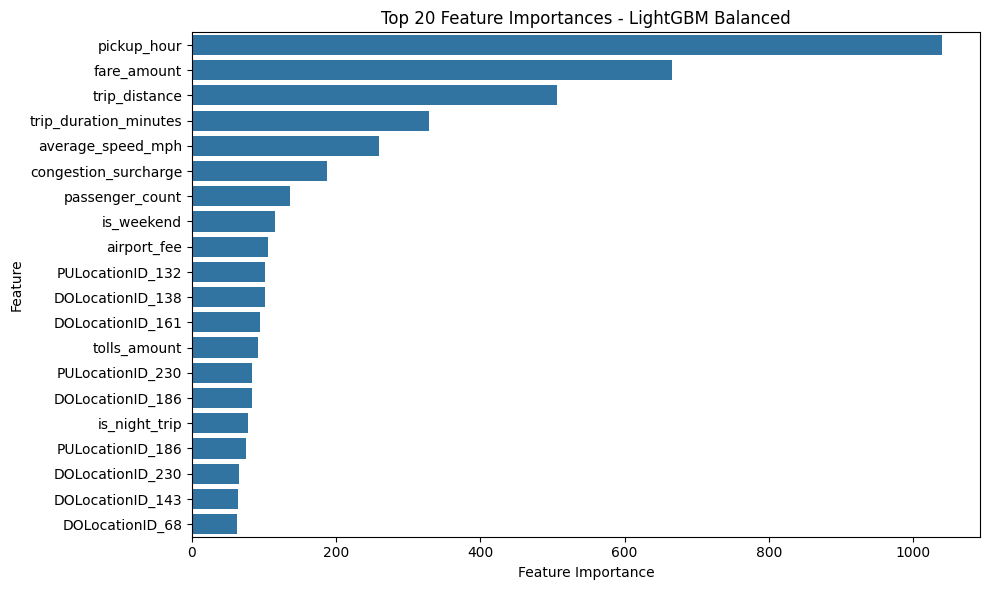

In [29]:
top_n = 20

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df.head(top_n),
    x="Importance",
    y="Clean Feature"
)

plt.title("Top 20 Feature Importances - LightGBM Balanced")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Model Interpretation: Feature Importance

The feature importance results from the LightGBM Balanced model show that both trip characteristics and contextual ride information are useful for predicting high-tip rides.

The most important feature is `pickup_hour`, suggesting that tipping behavior varies strongly across different times of the day. This is consistent with the EDA finding that customer tipping patterns may change by travel context, such as commuting hours, night trips, or leisure-related trips.

Fare and trip-related variables also appear highly important. Features such as `fare_amount`, `trip_distance`, `trip_duration_minutes`, and `average_speed_mph` indicate that completed ride characteristics are strongly associated with whether a trip receives a high tip. This suggests that the model uses information about ride length, cost, and travel efficiency to separate high-tip and low-tip rides.

Fare-condition variables such as `congestion_surcharge`, `airport_fee`, and `tolls_amount` also contribute to the prediction. These features may capture special trip contexts, such as airport rides, tolled routes, or trips in congested zones, which may have different tipping behavior compared with ordinary short city rides.

Location-based features, including `PULocationID` and `DOLocationID`, also appear among the top features. This suggests that pickup and drop-off areas contain useful spatial information for predicting tipping behavior. However, since this project does not use the taxi zone lookup table, these location IDs should be interpreted only as encoded area identifiers rather than named neighborhoods.

Overall, the model suggests that high-tip prediction is mainly associated with time of pickup, fare amount, trip distance, trip duration, travel speed, surcharges, and location patterns. These results should be interpreted as associations, not causal effects. In other words, the model identifies which features are useful for prediction, but it does not prove that these features directly cause passengers to tip more.